In [3]:
import pandas as pd
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
data=pd.read_csv('cleaned_dataset.csv')
data.head()

,Gender,Level,Age,CGPA,Exam Frequency,Better System,Stress Exam Type,Likert_MCQ_Objectivity,Likert_Written_Fairness,Likert_MCQ_Accuracy,Likert_MCQ_Guessing,Likert_Written_Depth,Likert_MCQ_Prep_Ease,Likert_Written_Measure,Likert_Written_Time_Stress,Likert_Stress_Comparison,Field_Category,Preferred_System_Type
0,1,1,1,3,2,0,1,5,3,5,5,5,5,4,3,4,Computer Science & IT,Practical/Project-Based
1,1,1,1,3.3,2,1,2,3,4,2,5,5,3,5,3,1,Data Science & AI,Mixed
2,0,0,0,-,2,0,0,1,1,1,1,1,1,1,1,1,High School Student,Other
3,0,1,1,2.7,2,2,1,3,2,4,4,3,5,3,4,4,Other,Other
4,1,1,1,3.2,1,0,1,5,2,4,5,1,5,2,5,5,Data Science & AI,Other


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188 entries, 0 to 187
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Gender                      188 non-null    int64 
 1   Level                       188 non-null    int64 
 2   Age                         188 non-null    int64 
 3   CGPA                        188 non-null    object
 4   Exam Frequency              188 non-null    int64 
 5   Better System               188 non-null    int64 
 6   Stress Exam Type            188 non-null    int64 
 7   Likert_MCQ_Objectivity      188 non-null    int64 
 8   Likert_Written_Fairness     188 non-null    int64 
 9   Likert_MCQ_Accuracy         188 non-null    int64 
 10  Likert_MCQ_Guessing         188 non-null    int64 
 11  Likert_Written_Depth        188 non-null    int64 
 12  Likert_MCQ_Prep_Ease        188 non-null    int64 
 13  Likert_Written_Measure      188 non-null    int64 

In [6]:
# Convert CGPA column to numeric and handle potential errors
data['CGPA'] = pd.to_numeric(data['CGPA'], errors='coerce')
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188 entries, 0 to 187
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Gender                      188 non-null    int64  
 1   Level                       188 non-null    int64  
 2   Age                         188 non-null    int64  
 3   CGPA                        174 non-null    float64
 4   Exam Frequency              188 non-null    int64  
 5   Better System               188 non-null    int64  
 6   Stress Exam Type            188 non-null    int64  
 7   Likert_MCQ_Objectivity      188 non-null    int64  
 8   Likert_Written_Fairness     188 non-null    int64  
 9   Likert_MCQ_Accuracy         188 non-null    int64  
 10  Likert_MCQ_Guessing         188 non-null    int64  
 11  Likert_Written_Depth        188 non-null    int64  
 12  Likert_MCQ_Prep_Ease        188 non-null    int64  
 13  Likert_Written_Measure      188 non

In [7]:
# Mean imputation for CGPA column
data['CGPA'] = data['CGPA'].fillna(data['CGPA'].mean())

In [8]:
data['Preferred_System_Type'].value_counts()

Preferred_System_Type
Other                      59
MCQ                        45
Mixed                      45
Practical/Project-Based    23
Written                    16
Name: count, dtype: int64

In [21]:
# T-Test: Compare Stress between MCQ and Written groups
# Filter groups
mcq_group = data[data['Preferred_System_Type'] == 'MCQ']['Likert_Stress_Comparison']
written_group = data[data['Preferred_System_Type'] == 'Written']['Likert_Stress_Comparison']

# Perform Independent Samples T-test
t_stat, p_value = stats.ttest_ind(mcq_group, written_group)

print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")

T-statistic: 1.0942727680683662
P-value: 0.27828276020517223


2. Chi-Square Test

In [ ]:
# Chi-Square test: Relationship between Gender and Preferred System Type

# Create contingency table
contingency_table = pd.crosstab(data['Gender'], data['Preferred_System_Type'])

# Perform Chi-Square test
chi2, p_val = stats.chi2_contingency(contingency_table)

print(f"Chi-Square Statistic: {chi2}")
print(f"P-value: {p_val}")

Chi-Square Statistic: 7.0456555638891425
P-value: 0.13349511838141526


In [ ]:
# Chi-Square test: Relationship between Field Category and Preferred System Type


# Create contingency table
field_system_table = pd.crosstab(data['Field_Category'], data['Preferred_System_Type'])

# Perform Chi-Square test
chi2, p_val = stats.chi2_contingency(field_system_table)

print(f"Chi-Square Statistic: {chi2}")
print(f"P-value: {p_val}")

Chi-Square Statistic: 28.833365456032695
P-value: 0.42101601734411753


3-Linear Regression

In [17]:
!pip install statsmodels

   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.6 MB ? eta -:--:--
   ----- ---------------------------------- 1.3/9.6 MB 3.9 MB/s eta 0:00:03
   -------- ------------------------------- 2.1/9.6 MB 3.9 MB/s eta 0:00:02
   ------------ --------------------------- 2.9/9.6 MB 3.9 MB/s eta 0:00:02
   --------------- ------------------------ 3.7/9.6 MB 3.9 MB/s eta 0:00:02
   ------------------ --------------------- 4.5/9.6 MB 3.9 MB/s eta 0:00:02
   --------------------- ------------------ 5.2/9.6 MB 3.7 MB/s eta 0:00:02
   ------------------------ --------------- 5.8/9.6 MB 3.6 MB/s eta 0:00:02
   ---------------------------- ----------- 6.8/9.6 MB 3.7 MB/s eta 0:00:01
   ------------------------------ --------- 7.3/9.6 MB 3.6 MB/s eta 0:00:01
   -------------------------------- ------- 7.9/9.6 MB 3.6 MB/s eta 0:00:01
   ----------------------------------- ---- 8.4/9.6 MB 3.4 MB/s eta 0:00:01
   -----------------------


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [19]:
# Calculate correlation of all numeric features with the target variable
correlations = data.select_dtypes(include=['number']).corr()['Likert_Written_Time_Stress'].sort_values(ascending=False)
print(correlations)

Likert_Written_Time_Stress    1.000000
Likert_Stress_Comparison      0.481427
Likert_MCQ_Guessing           0.245642
Likert_MCQ_Accuracy           0.199310
Likert_MCQ_Objectivity        0.180942
Stress Exam Type              0.110166
Likert_MCQ_Prep_Ease          0.109609
Gender                        0.067547
Age                           0.065097
Exam Frequency               -0.027800
Level                        -0.053580
CGPA                         -0.092267
Likert_Written_Fairness      -0.127573
Likert_Written_Depth         -0.132384
Likert_Written_Measure       -0.144780
Better System                -0.211468
Name: Likert_Written_Time_Stress, dtype: float64


In [8]:
# Multiple Linear Regression with optimized features
import statsmodels.api as sm

# Top correlated features based on correlation ranking
new_features = ['Likert_Stress_Comparison', 'Likert_MCQ_Guessing', 'Better System', 'Likert_Written_Measure']
X = data[new_features]
y = data['Likert_Written_Time_Stress']

# Add constant and fit the model
X = sm.add_constant(X)
optimized_model = sm.OLS(y, X).fit()

# Display summary
print(optimized_model.summary())

                                OLS Regression Results                                
Dep. Variable:     Likert_Written_Time_Stress   R-squared:                       0.298
Model:                                    OLS   Adj. R-squared:                  0.283
Method:                         Least Squares   F-statistic:                     19.42
Date:                        Mon, 27 Apr 2026   Prob (F-statistic):           2.46e-13
Time:                                15:38:19   Log-Likelihood:                -285.46
No. Observations:                         188   AIC:                             580.9
Df Residuals:                             183   BIC:                             597.1
Df Model:                                   4                                         
Covariance Type:                    nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------

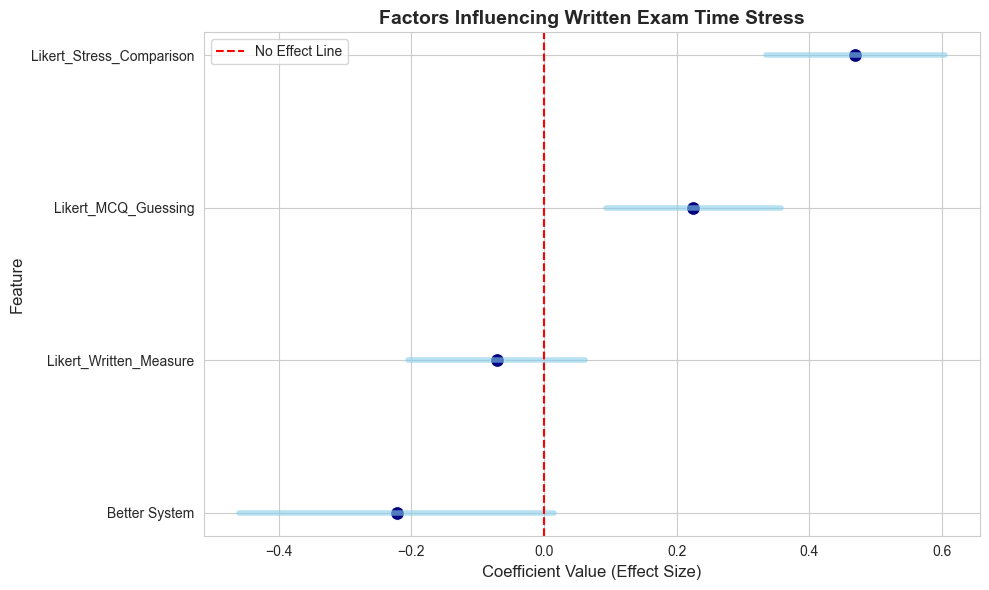

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Extract coefficients and confidence intervals from the model
coefs = optimized_model.params.drop('const') 
conf_int = optimized_model.conf_int().drop('const') 

# 2. Create a DataFrame to organize data for plotting
results_df = pd.DataFrame({
    'Feature': coefs.index,
    'Coefficient': coefs.values,
    'Lower CI': conf_int[0].values, 
    'Upper CI': conf_int[1].values  
})

# 3. Sort by coefficient value
results_df = results_df.sort_values(by='Coefficient', ascending=False)

# 4. Plot using Seaborn
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid") 

for i, row in results_df.iterrows():
    plt.plot([row['Lower CI'], row['Upper CI']], [row['Feature'], row['Feature']], 
             color='skyblue', linewidth=4, alpha=0.6)

sns.scatterplot(x='Coefficient', y='Feature', data=results_df, color='navy', s=100)

plt.axvline(x=0, color='red', linestyle='--', linewidth=1.5, label='No Effect Line')

plt.title('Factors Influencing Written Exam Time Stress', fontsize=14, fontweight='bold')
plt.xlabel('Coefficient Value (Effect Size)', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.legend()

plt.tight_layout()
plt.show()